In [1]:
import arviz as az
import pandas as pd
import json
import os

import numpy as np
import jax.numpy as jnp
import diffrax
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import jax
import sys

sys.path.append("../")
from utils import *
from plotting_helper_funcs import *

sys.path.append("../models/")
from MA_nonessential_diffrax import *

# tell jax to use 64bit floats
jax.config.update("jax_enable_x64", True)

mpl.rcParams['figure.autolayout'] = True

Set up: Models, data, etc.

In [2]:
sampler = "Pathfinder"

wt_color = sns.color_palette("colorblind")[0]

model = "MA_nonessential"
model_info_file = '../models/MA_nonessential.json'

data_dir = '../../../results/param_est/'
save_dir_base = '../../../results/param_est/stimulus_strength/'

save_dir = save_dir_base + model + '/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# load the model info
with open(model_info_file, 'r') as f:
    model_info = json.load(f)

state_names = list(model_info["init_conds"].keys())
ampkar_states = model_info['ampkar_states']
pampkar_states = model_info['pampkar_states']
y0 = list(model_info["init_conds"].values())

param_names = model_info["params"]

# get the indices of the states
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

# parameters for the metabolic model
metab_params_file = '../models/metabolism_params_Coccimiglio.json'
with open(metab_params_file, 'r') as file:
        metab_params = json.load(file)

basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values())

# load inference data (joint WT + LKB1kd model with shared parameters)
idata = az.from_netcdf(data_dir + model + '_Iono_mcmc_samples_' + sampler + '.nc')

# load data to get simulation time
_, _, times = load_data('../../../AMPKARkey_data/HeLaAMPKAR3_RCamp_Iono.npz',
                        to_seconds=True, constant_std=False, exclude_zero_std=True)

rtol = 1e-6
atol = 1e-6
evnt_rtol = 1e-12
evnt_atol = 1e-12
pcoeff = 0.3
icoeff = 0.4
dcoeff = 0.0
tmax_init = 1e3

Write a function to run all simulations and return the results. It takes the desired 
stimuli as the inputs

In [3]:
def compute_half_max(traj):
    """Compute the index of the time point where the trajectory reaches half its maximum value."""
    half_max = np.max(traj) / 2.0
    above = np.where(traj >= half_max)[0]
    if len(above) == 0:
        return len(traj) - 1
    return above[0]

def get_param_subsample_fixed(param_names, idata, n_traj, rng=np.random.default_rng(seed=1234)):
    """Extract parameter subsamples from posterior, handling array-valued constant_data."""
    dat = idata.posterior.to_dict()

    # get total samples from a scalar free parameter (skip WT/LKB1_KO which are arrays)
    free_param_samples_dict = {}
    fixed_params_value = {}
    for param in param_names:
        if param in dat['data_vars']:
            samples = np.array(dat['data_vars'][param]['data']).reshape(-1)
            free_param_samples_dict[param] = samples
        else:
            # constant_data may have shape (1,), extract scalar
            fixed_params_value[param] = float(idata.constant_data[param].values)

    n_samples = len(list(free_param_samples_dict.values())[0])
    idxs = rng.choice(np.arange(n_samples), size=n_traj, replace=False)

    param_samples = []
    for i in idxs:
        tmp = []
        for param in param_names:
            if param in free_param_samples_dict:
                tmp.append(float(free_param_samples_dict[param][i]))
            else:
                tmp.append(fixed_params_value[param])
        param_samples.append(tmp)

    return np.array(param_samples)

def run_model_sims(stim_strengths, idata, nsamples=4):
    """Run ODE simulations across varying stimulus strengths using posterior samples."""

    rhs = eval(model + '(' + ','.join(str(elm) for elm in basal_params) + ')')
    rhs = diffrax.ODETerm(rhs)

    # get params from the idata (shared parameters from the joint model)
    params = get_param_subsample_fixed(param_names, idata, nsamples)

    stress_sols = {}
    for key in stim_strengths.keys():
        stress_params_mod = stress_params.copy()
        stress_params_mod[0] = stim_strengths[key]  # update kGly

        rhs_stress = eval(model + '(' + ','.join(str(elm) for elm in stress_params_mod) + ')')
        rhs_stress = diffrax.ODETerm(rhs_stress)

        # run simulations for each parameter sample
        tmp = []
        for j in range(params.shape[0]):
            stress_sol, _ = solve_traj(rhs, rhs_stress, y0, params[j,:], times,
                rtol=rtol, atol=atol, evnt_rtol=evnt_rtol, evnt_atol=evnt_atol,
                tmax_init=tmax_init, pcoeff=pcoeff, icoeff=icoeff, dcoeff=dcoeff)

            AMPKAR_stressed = stress_sol[jnp.array(ampkar_idxs), :].sum(axis=0)
            pAMPKAR_stressed = stress_sol[jnp.array(pampkar_idxs), :].sum(axis=0)
            tmp.append(pAMPKAR_stressed / AMPKAR_stressed)

        stress_sols[key] = np.array(tmp)

    return stress_sols

Now actually run this. There is also the option to load previous results if they exist.

In [4]:
stim_strengths = {'0.4':0.4,     # weakest stimulus (basal k_gly = 0.5)
                  '0.3':0.3,
                  '0.2':0.2,
                  '0.1':0.1,
                  '0.075':0.075,
                  '0.05':0.05,
                  '0.025':0.025,
                  '0.01':0.01,
                  '0.005':0.005,  # level used during param est
                  }

run_sims = True
nsamples = 400
if run_sims:
    sol = run_model_sims(stim_strengths, idata, nsamples=nsamples)
    np.savez_compressed(save_dir + 'WT_stim_strength.npz', **sol)
    print("Finished running simulations!")
else:
    print("Loading simulations from file...")
    try:
        sol = np.load(save_dir + 'WT_stim_strength.npz')
    except FileNotFoundError as e:
        print("File not found. Please run the simulations first (set run_sims = True).")
        raise e

sol = {key: sol[key] for key in sol}

/var/folders/09/n6_5b4354s5f7bktpq84nk8w0000gp/T/ipykernel_73645/3737472853.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fixed_params_value[param] = float(idata.constant_data[param].values)


Finished running simulations!


Now process the results. Compute maximums and time to half maxes.

In [5]:
max_val = {stim: None for stim in stim_strengths.keys()}
t_half_max = {stim: None for stim in stim_strengths.keys()}

for stim in stim_strengths.keys():
    max_val[stim] = sol[stim][:, -1]

    t_half_idx = np.apply_along_axis(compute_half_max, 1, sol[stim])
    t_half_max[stim] = [times[idx] for idx in t_half_idx]

# convert to dataframes
df_max = pd.DataFrame(max_val)
df_max_long = df_max.melt(var_name='stimulus_strength', value_name='max_val')

df_t_half = pd.DataFrame(t_half_max)
df_t_half_long = df_t_half.melt(var_name='stimulus_strength', value_name='t_half_max')
df_t_half_long['t_half_max'] = df_t_half_long['t_half_max'] / 60  # convert to minutes

Plots

/var/folders/09/n6_5b4354s5f7bktpq84nk8w0000gp/T/ipykernel_73645/740036313.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Plots saved to ../../../results/param_est/stimulus_strength/MA_nonessential/


/var/folders/09/n6_5b4354s5f7bktpq84nk8w0000gp/T/ipykernel_73645/740036313.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


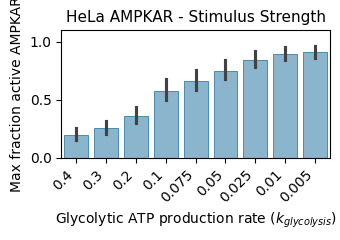

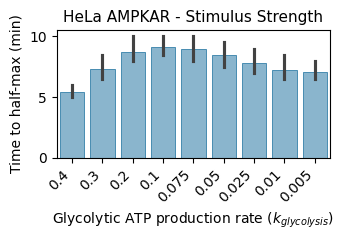

In [6]:
width = 3.5
height = 2.5

# max vals
fig, ax = plt.subplots(figsize=(width, height))

sns.barplot(data=df_max_long, x='stimulus_strength', y='max_val', color=wt_color, ax=ax,
    errorbar=('pi', 95))

ax.set_xlabel(r'Glycolytic ATP production rate ($k_{glycolysis}$)', fontsize=10)
ax.set_ylabel('Max fraction active AMPKAR', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('HeLa AMPKAR - Stimulus Strength', fontsize=11)

for patch in ax.patches:
    face_color = patch.get_facecolor()
    patch.set_facecolor(mpl.colors.to_rgba(face_color, alpha=0.5))
    patch.set_edgecolor(face_color)
    patch.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(save_dir + 'max_vals.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(save_dir + 'max_vals.png', dpi=300, bbox_inches='tight')

# time to half max
fig, ax = plt.subplots(figsize=(width, height))

sns.barplot(data=df_t_half_long, x='stimulus_strength', y='t_half_max', color=wt_color, ax=ax,
            errorbar=('pi', 95))

ax.set_xlabel(r'Glycolytic ATP production rate ($k_{glycolysis}$)', fontsize=10)
ax.set_ylabel('Time to half-max (min)', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('HeLa AMPKAR - Stimulus Strength', fontsize=11)

for patch in ax.patches:
    face_color = patch.get_facecolor()
    patch.set_facecolor(mpl.colors.to_rgba(face_color, alpha=0.5))
    patch.set_edgecolor(face_color)
    patch.set_linewidth(0.5)

fig.tight_layout()
fig.savefig(save_dir + 't_half_max.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(save_dir + 't_half_max.png', dpi=300, bbox_inches='tight')

print("Plots saved to", save_dir)